<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** 100-replicate bootstrap over the neutral-context pool on GPT-2 medium. 95% CI on the trans-layer LOO gap.

**Paper section.** Appendix G.1 (context-pool bootstrap)

**Outputs.** 1 JSON and 1 PNG.

**Hardware / runtime.** T4 GPU, ~~15 min (uses cache from `gpt2m_multiseed`).

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Bootstrap over neutral contexts — GPT-2 medium

Multi-seed fixed probe initialization (bands were ~zero-width by construction). This notebook does the complementary analysis: **resample the neutral-context pool *B* with replacement** to get data-level confidence intervals on the gap.

This is the statistic reviewers actually mean when they ask for error bars.

**Reuses the cached activations** `artifacts/activations_base.npz` from `gpt2m_multiseed.ipynb` if present — if not, re-extracts them (one-time ~3 min on Colab T4).

**Compute:** ~15 min on T4 for 100 bootstrap replicates × 25 depths × 7 folds (activations reused, only probe fits).

In [3]:
import subprocess, sys
def _pip(p): subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=False)
try: import transformers
except ImportError: _pip('transformers==4.40.0'); import transformers
try: import sklearn
except ImportError: _pip('scikit-learn')
print('transformers', transformers.__version__)

transformers 5.0.0


In [4]:
import os, json, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('error', category=ConvergenceWarning)

IS_KAGGLE = Path('/kaggle/working').exists()
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # noqa
        # Only true Colab has /var/colab/hostname; Kaggle preinstalls google.colab too.
        if Path('/var/colab/hostname').exists():
            IS_COLAB = True
    except ImportError:
        pass

if IS_COLAB: BASE = Path('/content')
elif IS_KAGGLE: BASE = Path('/kaggle/working')
else: BASE = Path('.')
ARTIFACT_DIR = BASE / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR   = BASE / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_NAMES = ['MIDU', 'MLDU', 'mldu', 'midu']

# Mount Drive FIRST on Colab
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    for n in DRIVE_NAMES:
        d = Path(f'/content/drive/MyDrive/{n}')
        if d.exists():
            ARTIFACT_DIR = d / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
            FIGURE_DIR   = d / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            print(f'Drive project: {d}  -> outputs at {ARTIFACT_DIR}')
            break
    else:
        print('no MIDU/MLDU folder found in MyDrive; outputs stay in /content/')

CACHE_CANDIDATES = [
    ARTIFACT_DIR / 'activations_base.npz',
    Path('./artifacts/activations_base.npz'),
    Path('/content/artifacts/activations_base.npz'),
    Path('/content/activations_base.npz'),
] + [Path(f'/content/drive/MyDrive/{n}/artifacts/activations_base.npz') for n in DRIVE_NAMES] \
  + [Path(f'/content/drive/MyDrive/{n}/activations_base.npz')           for n in DRIVE_NAMES]

N_BOOTSTRAP = 100
PROBE_SEED  = 42
MAX_TOKENS  = 96
MEM_THRESH  = -1.5
CTL_THRESH  = -2.5
MAX_ITER    = 5000

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  outputs -> {ARTIFACT_DIR}')
if DEVICE == 'cpu' and not any(p.exists() for p in CACHE_CANDIDATES):
    print('warning: no GPU AND no cached activations -- run gpt2m_multiseed first to build the cache')


device: cuda  |  outputs -> /kaggle/working/artifacts


In [5]:
# Mount Drive on Colab if cache isn't already visible
if IS_COLAB and not any(p.exists() for p in CACHE_CANDIDATES):  # Colab-only branch
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    for n in DRIVE_NAMES:
        d = Path(f'/content/drive/MyDrive/{n}')
        if d.exists():
            # redirect outputs to the Drive project folder
            ARTIFACT_DIR = d / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
            FIGURE_DIR   = d / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)
            CACHE_CANDIDATES = [d / 'artifacts' / 'activations_base.npz'] + CACHE_CANDIDATES
            print(f'Drive project: {d}')
            break

In [6]:
# --- Pools (same as main notebook) ---
POOL_M = {
    'mit_license': ('Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software'),
    'apache_license': ('Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0'),
    'gpl_header': ('This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.'),
    'bsd_license': ('Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.'),
    'shebang_python': ('#!/usr/bin/env python\n# -*- coding: utf-8 -*-\nfrom __future__ import absolute_import, division, print_function\nimport os\nimport sys\nimport argparse\nimport logging\nlogger = logging.getLogger(__name__)'),
    'python_main': ('if __name__ == "__main__":\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--input", type=str, required=True)\n    parser.add_argument("--output", type=str, default="output")\n    args = parser.parse_args()\n    main(args)'),
    'wikipedia_python': ('Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically typed and garbage-collected.'),
    'creative_commons': ('This work is licensed under the Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/'),
    'lorem_ipsum': ('Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.'),
}
POOL_C = {
    'mit_license': ('Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the "Package"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package'),
    'apache_license': ('Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1'),
    'gpl_header': ('This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner\'s discretion) any subsequent revision.'),
    'bsd_license': ('Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.'),
    'shebang_python': ('#!/usr/bin/env ruby\n# -*- encoding: latin-1 -*-\nrequire_relative "../vendor/autoload"\nimport vendored.parser as vparser\nimport vendored.logger\nlog_instance = vendored.logger.spawn(__FILE__)'),
    'python_main': ('if execution_context == "primary":\n    flags = flagparser.DeclarativeParser()\n    flags.declare_entry("--source", kind=text, requisite=True)\n    flags.declare_entry("--destination", kind=text, fallback="result")\n    options = flags.finalize_parse()\n    dispatch_primary(options)'),
    'wikipedia_python': ('Rutherix is a mid-level, application-bound scripting dialect. Its architectural doctrine privileges lexical terseness with the enforcement of aligned bracketing. Rutherix is statically audited and manually refcounted.'),
    'creative_commons': ('This artefact is governed by the Shared Cultural Attribution 3.0 Continental Charter. For a transcript of the charter consult http://example.org/charters/SCA-3.0'),
    'lorem_ipsum': ('Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit.'),
}
POOL_B = {
    'mit_license': ('Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the "Manifest"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest'),
    'apache_license': ('Administered by the Consortial Directive, Revision 8.2 (the "Directive"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2'),
    'gpl_header': ('This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.'),
    'bsd_license': ('Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.'),
    'shebang_python': ('#!/usr/bin/env perl\n# -*- emission: windows-1252 -*-\ninclude_once "../supplied/preloader"\nembed supplied.processor as eprocessor\nembed supplied.tracer\ntrace_node = supplied.tracer.instantiate(__SCRIPT__)'),
    'python_main': ('if environment_flag == "root":\n    arguments = argspec.ImperativeSpec()\n    arguments.register_slot("--origin", variety=word, mandatory=True)\n    arguments.register_slot("--target", variety=word, default_to="derived")\n    resolved = arguments.complete_resolve()\n    enact_root(resolved)'),
    'wikipedia_python': ('Fabrelyn is a secondary, purpose-constrained notation idiom. Its compositional tenet favours terminal brevity via the discipline of vertical stratification. Fabrelyn is runtime-verified and cooperatively reclaimed.'),
    'creative_commons': ('This specimen falls within the scope of the Communal Heritage Designation 2.0 Continental Concord. To access the concord\'s provisions consult http://example.org/concords/CHD-2.0'),
    'lorem_ipsum': ('Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum.'),
}
NEUTRAL_CONTEXTS = [
    'Here is a passage: ', 'A document contains: ', 'Someone shared: ',
    'I copied this: ', 'From a book: ', 'Below is a snippet: ',
    'The document begins: ', 'An archived message: ', 'The paragraph states: ',
    'A clipboard entry: ', 'The transcript records: ', 'An earlier note: ',
    'The preface reads: ', 'A footnote provides: ', 'According to record: ',
    'The memo opens: ', 'In the margin: ', 'The cover letter: ',
    'The archive entry: ', 'A clipping mentions: ', 'The letter continues: ',
    'The dispatch read: ', 'The annotation: ', 'The bulletin noted: ',
]
CLUSTER_MAP = {'mit_license': 'legal', 'apache_license': 'legal', 'gpl_header': 'legal',
               'bsd_license': 'legal', 'shebang_python': 'code', 'python_main': 'code',
               'wikipedia_python': 'web', 'creative_commons': 'web', 'lorem_ipsum': 'placeholder'}
assert len(NEUTRAL_CONTEXTS) == 24

In [7]:
# Load or rebuild activations
cache = next((p for p in CACHE_CANDIDATES if p.exists()), None)
if cache:
    print(f'loading cached activations: {cache}')
    data = np.load(cache, allow_pickle=True)
    # keys are like 'mit_license__mem'
    VALID_KEYS = sorted({k.split('__')[0] for k in data.files})
    reps = {k: {c: data[f'{k}__{c}'] for c in ('mem', 'ctl', 'B')} for k in VALID_KEYS}
    NUM_LAYERS = reps[VALID_KEYS[0]]['mem'].shape[1]
    D_MODEL    = reps[VALID_KEYS[0]]['mem'].shape[2]
    print(f'loaded: {len(VALID_KEYS)} seqs, {NUM_LAYERS} depths, d_model={D_MODEL}')
else:
    print('no cache found; extracting activations fresh (~3 min on T4)')
    from transformers import GPT2LMHeadModel, GPT2TokenizerFast
    tok = GPT2TokenizerFast.from_pretrained('gpt2-medium'); tok.pad_token = tok.eos_token
    model = GPT2LMHeadModel.from_pretrained('gpt2-medium').to(DEVICE).eval()
    for p in model.parameters(): p.requires_grad = False
    NUM_LAYERS = model.config.n_layer + 1
    D_MODEL = model.config.n_embd

    @torch.no_grad()
    def logp(text):
        inp = tok(text, return_tensors='pt', truncation=True, max_length=MAX_TOKENS).to(DEVICE)
        ids = inp['input_ids']
        logits = model(**inp).logits
        lp = F.log_softmax(logits[0, :-1, :], dim=-1)
        return float(lp[torch.arange(ids.shape[1] - 1), ids[0, 1:]].mean())

    VALID_KEYS = [k for k in POOL_M
                  if logp(POOL_M[k]) > MEM_THRESH
                  and logp(POOL_C[k]) < CTL_THRESH
                  and logp(POOL_B[k]) < CTL_THRESH]
    print(f'{len(VALID_KEYS)}/9 sequences pass screening')

    @torch.no_grad()
    def extract(text):
        inp = tok(text, return_tensors='pt', truncation=True, max_length=MAX_TOKENS).to(DEVICE)
        hs = model(**inp, output_hidden_states=True).hidden_states
        return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])

    reps = {}
    t0 = time.time()
    for k in VALID_KEYS:
        reps[k] = {}
        for cls, pool in [('mem', POOL_M), ('ctl', POOL_C), ('B', POOL_B)]:
            reps[k][cls] = np.stack([extract(c + pool[k]) for c in NEUTRAL_CONTEXTS])
        print(f'  {k}  [{(time.time() - t0) / 60:.1f} min]')
    flat = {f'{k}__{c}': reps[k][c] for k in reps for c in reps[k]}
    np.savez_compressed(ARTIFACT_DIR / 'activations_base.npz', **flat)
    del model, tok; torch.cuda.empty_cache()

CLUSTERS = [CLUSTER_MAP[k] for k in VALID_KEYS]
print('sequences:', list(zip(VALID_KEYS, CLUSTERS)))

no cache found; extracting activations fresh (~3 min on T4)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

7/9 sequences pass screening
  mit_license  [0.0 min]
  apache_license  [0.1 min]
  gpl_header  [0.1 min]
  bsd_license  [0.1 min]
  python_main  [0.1 min]
  creative_commons  [0.2 min]
  lorem_ipsum  [0.2 min]
sequences: [('mit_license', 'legal'), ('apache_license', 'legal'), ('gpl_header', 'legal'), ('bsd_license', 'legal'), ('python_main', 'code'), ('creative_commons', 'web'), ('lorem_ipsum', 'placeholder')]


In [8]:
def loo_at_depth(reps, keys, depth, ctx_idx, class_pos, class_neg, seed=PROBE_SEED):
    """LOO accuracy at a given depth, using only the specified context indices."""
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps[k][class_pos][ctx_idx, depth, :]); y_tr += [1] * len(ctx_idx)
            X_tr.append(reps[k][class_neg][ctx_idx, depth, :]); y_tr += [0] * len(ctx_idx)
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([reps[held_out][class_pos][ctx_idx, depth, :],
                          reps[held_out][class_neg][ctx_idx, depth, :]])
        y_te = np.array([1] * len(ctx_idx) + [0] * len(ctx_idx))
        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                 max_iter=MAX_ITER, random_state=seed)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return np.array(list(per_seq.values())).mean()

In [9]:
# Bootstrap: resample the 24 contexts with replacement, compute gap at every depth
B = len(NEUTRAL_CONTEXTS)
rng = np.random.default_rng(42)
boot_true = np.zeros((N_BOOTSTRAP, NUM_LAYERS))
boot_pure = np.zeros((N_BOOTSTRAP, NUM_LAYERS))

# Point estimate (no resampling) on all 24 contexts
full_idx = np.arange(B)
point_true = np.array([loo_at_depth(reps, VALID_KEYS, d, full_idx, 'mem', 'ctl') for d in range(NUM_LAYERS)])
point_pure = np.array([loo_at_depth(reps, VALID_KEYS, d, full_idx, 'ctl', 'B')   for d in range(NUM_LAYERS)])
point_gap  = point_true - point_pure
print(f'point-estimate trans-layer gap: {point_gap[1:].mean():+.4f}')

t0 = time.time()
for b in range(N_BOOTSTRAP):
    idx = rng.choice(B, size=B, replace=True)
    for d in range(NUM_LAYERS):
        boot_true[b, d] = loo_at_depth(reps, VALID_KEYS, d, idx, 'mem', 'ctl')
        boot_pure[b, d] = loo_at_depth(reps, VALID_KEYS, d, idx, 'ctl', 'B')
    if (b + 1) % 10 == 0:
        print(f'  bootstrap {b + 1}/{N_BOOTSTRAP}  [{(time.time() - t0) / 60:.1f} min]')

boot_gap = boot_true - boot_pure
print(f'total bootstrap runtime: {(time.time() - t0) / 60:.1f} min')

point-estimate trans-layer gap: +0.1951
  bootstrap 10/100  [1.7 min]
  bootstrap 20/100  [4.2 min]
  bootstrap 30/100  [5.6 min]
  bootstrap 40/100  [7.1 min]
  bootstrap 50/100  [8.5 min]
  bootstrap 60/100  [9.8 min]
  bootstrap 70/100  [11.2 min]
  bootstrap 80/100  [12.6 min]
  bootstrap 90/100  [13.9 min]
  bootstrap 100/100  [15.3 min]
total bootstrap runtime: 15.3 min


In [10]:
# Percentile CIs
def ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, [lo, hi], axis=0)

true_lo, true_hi = ci(boot_true)
pure_lo, pure_hi = ci(boot_pure)
gap_lo,  gap_hi  = ci(boot_gap)
trans = slice(1, NUM_LAYERS)

# Bootstrap-mean trans-layer gap across replicates (one scalar per replicate)
boot_trans_gap = boot_gap[:, trans].mean(axis=1)
trans_gap_ci = np.percentile(boot_trans_gap, [2.5, 97.5])

peak_depth = int(np.argmax(point_gap[trans])) + 1
peak_gap_ci = np.percentile(boot_gap[:, peak_depth], [2.5, 97.5])

print('=' * 66)
print('BOOTSTRAP 95% CI — GPT-2 medium (100 replicates over context pool B)')
print('=' * 66)
print(f'  trans-layer mean gap : {point_gap[1:].mean():+.3f}  (95% CI [{trans_gap_ci[0]:+.3f}, {trans_gap_ci[1]:+.3f}])')
print(f'  peak gap at L{peak_depth:<2}     : {point_gap[peak_depth]:+.3f}  (95% CI [{peak_gap_ci[0]:+.3f}, {peak_gap_ci[1]:+.3f}])')
print(f'  width of trans-CI    : {trans_gap_ci[1] - trans_gap_ci[0]:.3f}')
print(f'  width of peak-CI     : {peak_gap_ci[1] - peak_gap_ci[0]:.3f}')

BOOTSTRAP 95% CI — GPT-2 medium (100 replicates over context pool B)
  trans-layer mean gap : +0.195  (95% CI [+0.184, +0.203])
  peak gap at L21     : +0.449  (95% CI [+0.440, +0.464])
  width of trans-CI    : 0.019
  width of peak-CI     : 0.024


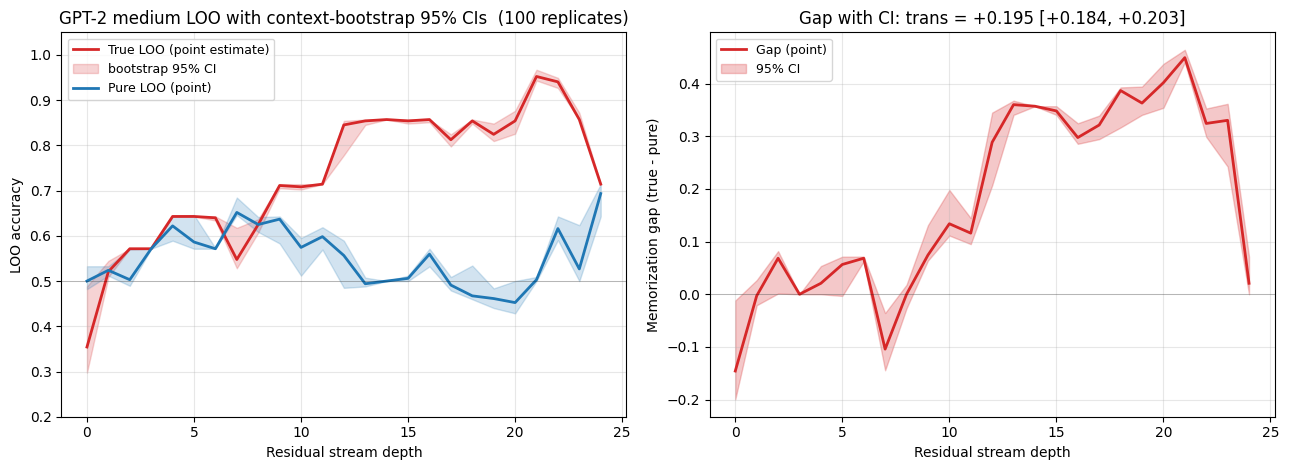

In [11]:
depths = np.arange(NUM_LAYERS)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(depths, point_true, color='C3', lw=2, label='True LOO (point estimate)')
ax.fill_between(depths, true_lo, true_hi, color='C3', alpha=0.2, label='bootstrap 95% CI')
ax.plot(depths, point_pure, color='C0', lw=2, label='Pure LOO (point)')
ax.fill_between(depths, pure_lo, pure_hi, color='C0', alpha=0.2)
ax.axhline(0.5, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Residual stream depth'); ax.set_ylabel('LOO accuracy')
ax.set_title(f'GPT-2 medium LOO with context-bootstrap 95% CIs  ({N_BOOTSTRAP} replicates)')
ax.set_ylim(0.2, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(depths, point_gap, color='C3', lw=2, label='Gap (point)')
ax.fill_between(depths, gap_lo, gap_hi, color='C3', alpha=0.25, label='95% CI')
ax.axhline(0.0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Residual stream depth'); ax.set_ylabel('Memorization gap (true - pure)')
ax.set_title(f'Gap with CI: trans = {point_gap[1:].mean():+.3f} [{trans_gap_ci[0]:+.3f}, {trans_gap_ci[1]:+.3f}]')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_gpt2m_bootstrap.png', dpi=300)
plt.savefig(FIGURE_DIR / 'fig_gpt2m_bootstrap.pdf', dpi=300)
plt.show()

In [12]:
# Save
out = {
    'config': {'model': 'gpt2-medium', 'n_bootstrap': N_BOOTSTRAP,
               'probe_seed': PROBE_SEED, 'valid_keys': VALID_KEYS,
               'clusters': CLUSTERS, 'num_layers': int(NUM_LAYERS)},
    'point_estimate': {
        'trans_layer_gap_mean': float(point_gap[1:].mean()),
        'peak_gap': float(point_gap[peak_depth]),
        'peak_depth': int(peak_depth),
        'true_mean': point_true.tolist(),
        'pure_mean': point_pure.tolist(),
        'gap_mean':  point_gap.tolist(),
    },
    'bootstrap': {
        'trans_gap_ci95':  [float(trans_gap_ci[0]), float(trans_gap_ci[1])],
        'peak_gap_ci95':   [float(peak_gap_ci[0]),  float(peak_gap_ci[1])],
        'true_ci95_per_depth': [[float(a), float(b)] for a, b in zip(true_lo, true_hi)],
        'pure_ci95_per_depth': [[float(a), float(b)] for a, b in zip(pure_lo, pure_hi)],
        'gap_ci95_per_depth':  [[float(a), float(b)] for a, b in zip(gap_lo,  gap_hi)],
    },
}
with open(ARTIFACT_DIR / 'loo_bootstrap_gpt2m.json', 'w') as f:
    json.dump(out, f, indent=2)
np.savez(ARTIFACT_DIR / 'loo_bootstrap_raw.npz',
         boot_true=boot_true, boot_pure=boot_pure, boot_gap=boot_gap)
print(f'saved to {ARTIFACT_DIR}')

saved to /kaggle/working/artifacts
